# Convolutional Neural Network - Pytorch 

The following libraries are required to run this module.

In [92]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

The CIFAR-10 dataset is loaded directly from torchvision. It is split into training set (50,000 images) and test set (10,000 images). Both sets contain 32x32 RGB images across 10 mutually exclusive classes.

In [94]:
train_df = torchvision.datasets.CIFAR10(
    root="data",
    train=True,
    download=True
)

test_df = torchvision.datasets.CIFAR10(
    root="data",
    train=False,
    download=True
)

train_df.data.shape, test_df.data.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

Based on the dataset, each image in CIFAR-10 has the following dimensions:

In [95]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3

Images are converted from PIL fromat to tensors. The same transform is applied to both the training and test sets.

In [96]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_df.transform = transform
test_df.transform = transform

Let's display some sample images from the training set with their class labels. This step was generated by AI because is out of the scope of the main task.

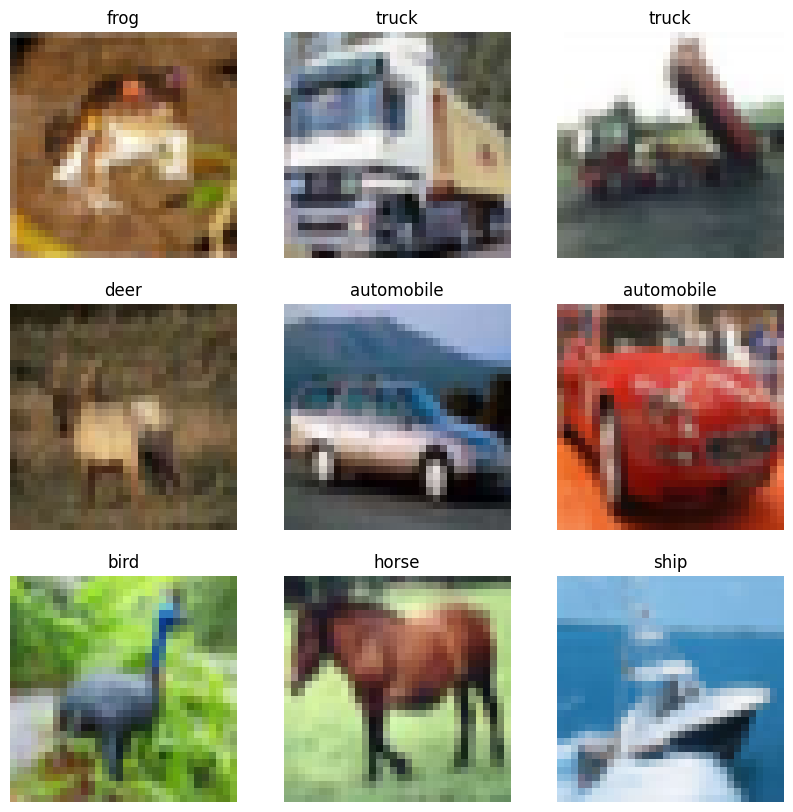

In [97]:
# Generated by AI
class_names = train_df.classes
images, labels = train_df.data[:9], train_df.targets[:9]

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

We need to create dataloaders for our training and test datasets. Dataloaders will allow us to load our data in batches, which is essential for training our model efficiently. We will use a batch size of 32 for both the training and test dataloaders.

In [98]:
batch_size = 32
train_dataloader = DataLoader(train_df, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_df, batch_size=batch_size, shuffle=False)

Now, let's define the training and testing loops. The following functions are the same as seen in class.

In [99]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [100]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        test_loss = 0.0
        test_acc = 0.0
        with torch.no_grad():
            for X_test, y_test in _test_loader:
                test_outputs = _model(X_test)
                test_loss += _criterion(test_outputs, y_test).item() * X_test.size(0)
                test_acc += get_batch_accuracy(test_outputs, y_test, len(_test_loader.dataset))

        epoch_test_loss = test_loss / len(_test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{test_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(test_acc)

    return res

In [101]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

### First Convolutional Neural Network

Now, we have our data in the form of tensors, we can start building a model. Let's create a simple convolutional neural network (CNN) using PyTorch's `nn.Module`.

In [102]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Dropout(.3),       
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(64, 64, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),
    nn.Linear(64 * 4 * 4, 256), 
    nn.Dropout(.5),           
    nn.ReLU(),
    nn.Linear(256, 10)
)

model_cnn = model_cnn.to(device)

Then, we need to define a loss function and an optimizer for training the model. We will use `CrossEntropyLoss` as the loss function and Adam as the optimizer. Also, we will set the number of epochs for training the model. `CrossEntropyLoss` is selected because CIFAR-10 is a multiclass classification problem. 

In [103]:
epochs = 20
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

Now, let's train the first model.

In [104]:
cnn_res = train(model_cnn, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Training: 100%|██████████| 20/20 [14:55<00:00, 44.77s/epoch, test_acc=0.7861, test_loss=0.6412, train_acc=0.8369, train_loss=0.4615]


The following graph shows the learning curves for train and test loss accros epochs.

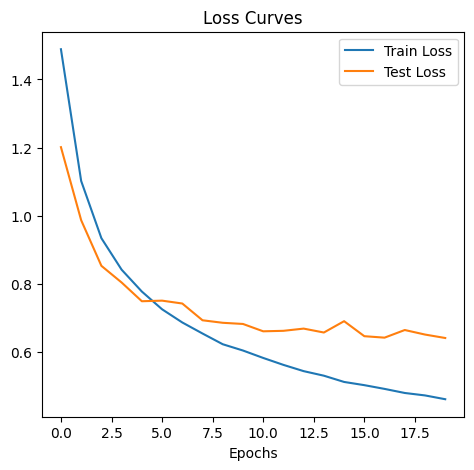

In [105]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['test_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.legend()
plt.show()

### Second Convolutional Neural Network

In [106]:
model_cnn_2 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1), # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), # 25 x 16 x 16

    nn.Conv2d(25, 50, 3, stride=1, padding=1), # 50 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2), # 50 x 8 x 8

    nn.Conv2d(50, 75, 3, stride=1, padding=1), # 75 x 8 x 8
    nn.ReLU(),  
    nn.MaxPool2d(2, stride=2), # 75 x 4 x 4
    
    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10)
)

model_cnn_2 = model_cnn_2.to(device)

In [107]:
epochs = 20
optimizer = torch.optim.Adam(model_cnn_2.parameters(), lr=0.001, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

In [108]:
cnn_res_2 = train(model_cnn_2, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Training: 100%|██████████| 20/20 [14:13<00:00, 42.67s/epoch, test_acc=0.7754, test_loss=0.7837, train_acc=0.9065, train_loss=0.2632]


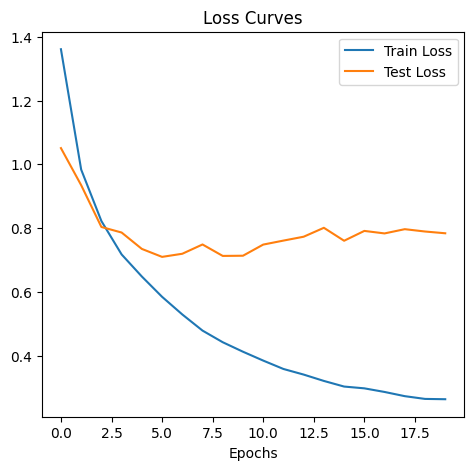

In [109]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_res_2['train_loss'], label='Train Loss')
plt.plot(cnn_res_2['test_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.legend()
plt.show()

### Third Convolutional Neural Network

In [110]:
model_cnn_3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(32, 64, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.Dropout(.5),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(64, 128, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), 

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.Dropout(.5),
    nn.ReLU(),
    nn.Linear(512, 10)
)

model_cnn_3 = model_cnn_3.to(device)

In [111]:
epochs = 20
optimizer = torch.optim.Adam(model_cnn_3.parameters(), lr=0.0001, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

In [112]:
cnn_res_3 = train(model_cnn_3, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Training: 100%|██████████| 20/20 [18:07<00:00, 54.36s/epoch, test_acc=0.7459, test_loss=0.7738, train_acc=0.8076, train_loss=0.5490]


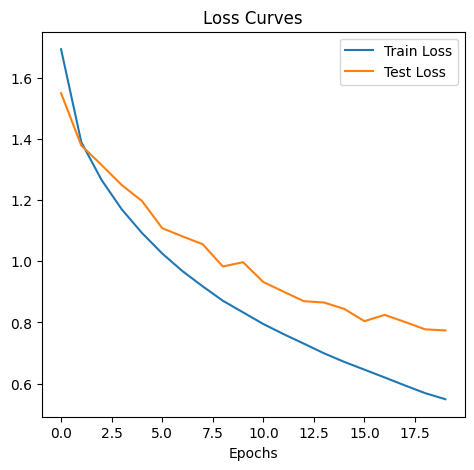

In [113]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_res_3['train_loss'], label='Train Loss')
plt.plot(cnn_res_3['test_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.legend()
plt.show()

Now, evaluate the models on the test set and compare their performance.


In [114]:
models = [model_cnn, model_cnn_2, model_cnn_3]
results = []
for model in models:
    test_loss, test_acc = test(model, test_dataloader, loss_fn)
    results.append((test_loss, test_acc))

for i, (loss, acc) in enumerate(results):
    print(f"Model {i+1}: Test Loss = {loss:.4f}, Test Accuracy = {acc:.4f}")

Model 1: Test Loss = 0.6412, Test Accuracy = 0.7861
Model 2: Test Loss = 0.7837, Test Accuracy = 0.7754
Model 3: Test Loss = 0.7738, Test Accuracy = 0.7459


## Final Remarks

In this notebook, I had the opportunity to experiment with Convolutional Neural Networks. It was interesting because first I had to select the proper hyperparameters and then just focus on the model architecture. But the interesting part of it was that the first model was the best model based on the test accuracy. The first model had overfitting, and I tried to add some methods to reduce it, but they did not work very well. However, it showed the best results out of these three models, even though I did not use a lot of layers in the architecture. 

For the second model, I just changed the Dropout in the CNN, as a result, we did not see much difference between the first and second models. Then, in the third model, I tried to add more layers, but the results were not great. The accuracy dropped, so the model was not learning well, and we could also see overfitting. This means that even if we generate a complex architecture for a CNN, it does not guarantee that the model is going to have a great performance, so you have to understand the data you are working with.

Finally, this exercise was great, it allowed me to play with some CNNs and see how you can structure them to achieve better results.